# Projet CSAA - Classification du rythme cardiaque issu d'ECG


Ce jeu de données est composé d'une collections de signaux de battements cardiaques provenant d'un jeu de données célèbres dans le domaine de la classification des battements cardiaques, le jeu de données sur l'arythmie du MIT-BIH.

Les signaux correspondent à des formes d'électrocardiogramme (ECG) de battements cardiaques pour le cas normal et les cas affectés par différentes arythmies et infarctus du myocarde. Ces signaux sont prétraités et segmentés, chaque segment correspondant à un battement cardiaque.

<img src="./DataECG.png" width="800" height="600">

On distingue 5 battements cardiaques différents : Battements normaux', 'Battements inconnus', 'Battements ectopiques ventriculaires', 'Battements ectopiques supraventriculaires' et 'Battements de fusion'.

De ces signaux, on extrait des caractéristiques par la librairie TSFEL - *Time Series Features Extraction Library* (https://tsfel.readthedocs.io/en/latest/index.html)

Les 156 caractéristiques extraites sont divisées selon les domaines :
- temporel avec 31 caractéristiques comme l'entropie, Max, Min, Absolute Energy ...
- statistique avec 14 caractéristiques comme écart moyen absolu, écart médian, variance, Kurtosis...
- spectral  avec 111 caractéristiques comme les coefficients FFT par bande de fréquence, ondelettes...

Lien vers le papier expliquant TSFEL : https://www.sciencedirect.com/science/article/pii/S2352711020300017

In [1]:
from google.colab import files

uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [2]:
# Librairies utiles
import numpy as np
from math import *
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn import svm
from sklearn import tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# Chargement des données d'apprentissage et de test

In [3]:
# Chargement des données brutes
DataECGFull=np.load('./DataECG.npy')
print('Taille du dataset ECG:', DataECGFull.shape)

# Après extraction des features
# Chargement des données d'apprentissage
DataFeature=np.load('./DataFeature.npy')
Label=np.load('./Label.npy')
print('Taille du dataset après extraction de features :', DataFeature.shape, Label.shape)


# Séparation en ensemble d'apprentissage et de test
from sklearn.model_selection import train_test_split

DataECGApp, DataECGTest, Label_train, Label_test = train_test_split(DataECGFull, Label, test_size=0.2, random_state=42)
DataFeatureApp, DataFeatureTest, LabelF_train, LabelF_test = train_test_split(DataFeature, Label, test_size=0.2, random_state=42)

print('Taille de la base d apprentissage ECG :', DataECGApp.shape, 'Taille du dataset de test ECG :', DataECGTest.shape)
print('Taille de la base d apprentissage Features :', DataFeatureApp.shape, 'Taille du dataset de test Features :', DataFeatureTest.shape)


FileNotFoundError: [Errno 2] No such file or directory: './DataECG.npy'

In [ ]:
DataECGFull

array([[0.1627907 , 0.54069769, 0.75581396, ..., 0.        , 0.        ,
        0.        ],
       [0.99006623, 0.93874174, 0.34437087, ..., 0.        , 0.        ,
        0.        ],
       [0.97423887, 0.93208432, 0.59016395, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.        , 0.56175297, 0.61354584, ..., 0.        , 0.        ,
        4.        ],
       [0.60000002, 0.49642858, 0.39464286, ..., 0.        , 0.        ,
        4.        ],
       [0.92196208, 0.87848383, 0.83166111, ..., 0.        , 0.        ,
        4.        ]])

In [ ]:
Label

array([0., 0., 0., ..., 4., 4., 4.])

In [ ]:
len(DataECGApp)

4000

# Chargement des variables issues *TSFEL*

In [3]:
ListeVariablesStat=np.load('./ListeVariableStat.npy',allow_pickle=True)
print('Nombre de variables statistiques :',ListeVariablesStat.shape)
#print('Liste Variables Statistiques :', ListeVariablesStat)

ListeVariablesTemps=np.load('./ListeVariableTemps.npy',allow_pickle=True)
print('Nombre de variables temporelles :',ListeVariablesTemps.shape)
#print('Liste Variables Temporelles :',ListeVariablesTemps)

ListeVariablesSpectral=np.load('./ListeVariableSpectral.npy',allow_pickle=True)
print('Nombre de variables spectrales :',ListeVariablesSpectral.shape)
#print('Liste Variables Spectrales :',ListeVariablesSpectral)

Nombre de variables statistiques : (31,)
Nombre de variables temporelles : (14,)
Nombre de variables spectrales : (111,)


### Fonctions pour réaliser une table de correspondance entre le label des approches non supervisées et le label réel

In [4]:
def retrieve_info(cluster_labels,y_train):
 #Associe l'étiquette la plus probable à chaque groupe dans le modèle KMeans.
 #Résultats : dictionnaire des clusters associés à chaque étiquette.

# Initialisation
  reference_labels = np.zeros((len(np.unique(cluster_labels)),1))
# Loop pour chaque label
  for i in range(len(np.unique(cluster_labels))):
    index = np.where(cluster_labels == i,1,0)
    num = np.bincount(y_train[index==1]).argmax()
    reference_labels[i] = num
  return reference_labels

def correspondance(y_pred_kmeans,y_train):
  # Correspondance entre la partition et les classes de la vérité terrain
  reference_labels = retrieve_info(y_pred_kmeans,y_train)
  number_labels = np.zeros(len(y_pred_kmeans))
  for i in range(len(y_pred_kmeans)):
    number_labels[i] = reference_labels[y_pred_kmeans[i]]
  return number_labels


# Partie I : Implémentation de l'algorithme de programmation dynamique (DTW)

1. Ecrivez une fonction en python DTW qui implémente le calcul et l'affichage de la matrice des coûts définie en TD.



In [5]:
def DTW(I, J, d):

    N, M = len(I), len(J)
    g = np.full((N , M ), np.inf)
    g[0, 0] = 0

    w0, w1, w2 = 1, 2, 1

    # Calcul des coûts
    for i in range(1, N ):
        for j in range(1, M ):
            cost = d(I[i], J[j])  # Calcul de la distance locale
            g[i, j] = min(
                g[i - 1, j] + w0 * cost,
                g[i - 1, j - 1] + w1 * cost,
                g[i, j - 1] + w2 * cost
            )

    # Calcul du score d'alignement
    Score = g[N-1, M-1] / (N + M)

    return g, Score



In [ ]:
# Ici , on cherche les représentants de chacun des 5 labels , en regroupant d'abord les profils issues de la même classe
# puis , on prend le median pour avoir un représentant de cette classe

representant_labels = []
labels = [0 ,1 ,2 ,3 ,4]
list_label = []
for label in labels :
  label_i = []
  for iter in range(0,len(Label_train)) :
    if Label_train[iter] == label :
      label_i.append(iter)
  list_label.append(label_i)

representant_labels = [np.median(DataECGApp[list_label[i]] , axis = 0 ) for i in labels]



## Système de reconnaissance de battements cardiaques par DTW



**Système de reconnaissance :**
Pour chaque profil temporel test :

a) Calculer pour chaque classe, le score de la DTW entre le profil temporel test et les profils temporels de la classe

b) Déterminer la classe d'appartenance par minimum du score sur toutes les classes


In [ ]:
# On teste avec la distance |x-y|
def distance(a,b):
    return abs(a - b)

In [ ]:
def find_index(x,L):
    if x not in L :
        return "élement non trouvé"
    else :
      index = 0
      while L[index] != x :
         index += 1
      return index


In [ ]:
# L'excustion de cette cette cellule de code peut prendre un certain temps 
# (Le temps d'execution dépend de la distance choisie) 

classes_test = [] # La liste qui contient la classe d'appartenance de chaque profil test

# On parcourt sur l'ensemble des profils test
for i in range(0,len(DataECGTest)):
    score_i = [] # La liste de toutes les valeurs des scores calculées avec la fonction DTW

    # On parcours sur l'ensemble des classes (il y'a 5 représentants de chaque classe)
    for j in range(0,len(representant_labels)) :
        [g , score] = DTW(DataECGTest[i,:]  , representant_labels[j] , distance)
        score_i.append(score)

    classe_i = find_index(min(score_i) , score_i) # ça sera la classe d'apparetenance du profil i

    classes_test.append(float(classe_i))


In [ ]:
np.shape(DataECGTest)

(1000, 188)

In [ ]:
len(classes_test)

1000

In [ ]:
TAILLE_TEST  = np.shape(DataECGTest)[0] # Le nombre d'échantillons de test
N_CLASSES = len(np.unique(Label_train))
print(TAILLE_TEST)
print(N_CLASSES)

1000
5


In [ ]:
# Système de reconnaissance à partir de la DTW
#PartitionDTW=np.zeros((TAILLE_TEST * N_CLASSES,2))
## à coder
PartitionDTW=np.zeros((TAILLE_TEST * 1,2))
PartitionDTW[:,0] = Label_test
PartitionDTW[:,1] = classes_test


In [ ]:
PartitionDTW

array([[1., 1.],
       [2., 1.],
       [2., 4.],
       ...,
       [3., 3.],
       [2., 2.],
       [1., 1.]])

**Evaluation :** A partir de la partition de l'ensemble test obtenue après la DTW, calculer la matrice de confusion qui recense le nombre de données bien classés et mal classés.

Matrice de confusion par DTW
Accuracy sur la base de test : 0.648


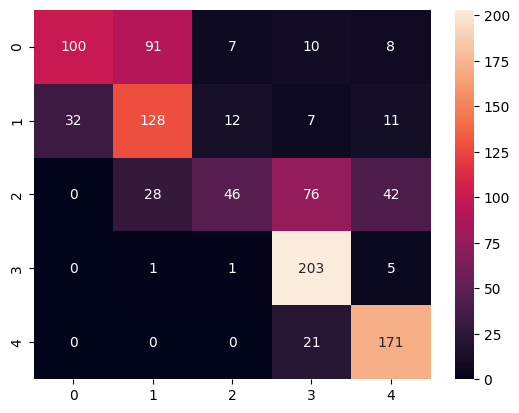

In [ ]:
print('Matrice de confusion par DTW')
cm=confusion_matrix(Label_test,classes_test)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur la base de test :',accuracy_score(PartitionDTW[:,0],PartitionDTW[:,1]))
#print('Loss sur base de test :',log_loss(PartitionDTW[:,0],PartitionDTW[:,1]))

# Partie II : Classification des battements cardiaques sur les features sans prétraitement

Réaliser une classification des battements cardiaques par une méthode d'apprentissage supervisé et une méthode d'apprentissage non supervisé de votre choix en utilisant la librairie *scikit-learn*.

Pour chaque résultat obtenu, calculer la matrice de confusion et interpréter les résultats.


## Méthodes supervisées  :
indiquer quelles sont les 2 méthodes supervisées de votre choix et calculer la matrice de confusion associée.

### On pourra opter à travailler avec du SVM et les Arbres de décision

### 1- Avec la méthode $SVM$

In [6]:
# Les inputs et les outputs d'entrainetement
x = DataECGApp
y = Label_train

# Avec un kernel Linéair
lin_clf = svm.LinearSVC()

# Feeding the training data to the clf
lin_clf.fit(x, y)

LinearSVC()

In [7]:
# Test sur les échantillons de DataECG_Test
x_test = DataECGTest
y_true = Label_test
y_pred = lin_clf.predict(x_test)

Matrice de confusion par SVM avec un noyau linéair
Accuracy sur base de test : 0.922


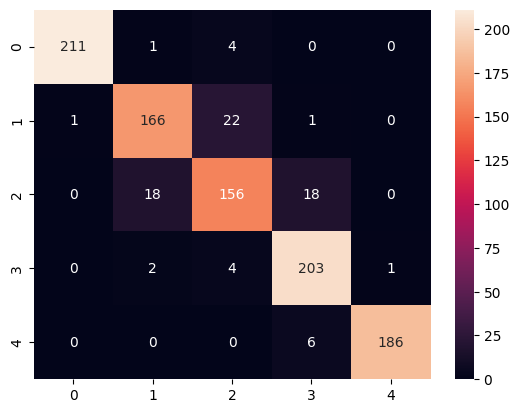

In [8]:
print('Matrice de confusion par SVM avec un noyau linéair')
cm=confusion_matrix(y_true,y_pred)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(y_true,y_pred))

### 2- Avec la méthode $Arbres$ $de$ $décision$

In [9]:
# Les inputs et les outputs d'entrainetement
x = DataECGApp
y = Label_train

# Entrainer le classifieur
clf = tree.DecisionTreeClassifier()
clf = clf.fit(x, y)

In [10]:
# Test sur les échantillons de DataECG_Test
x_test = DataECGTest
y_true = Label_test
y_pred_DT = clf.predict(x_test)

Matrice de confusion avec les arbres de décision
Accuracy sur base de test : 1.0


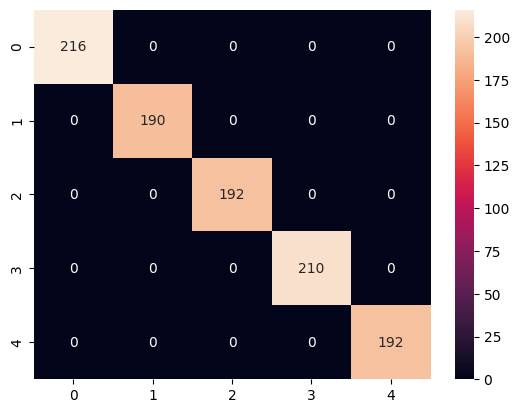

In [11]:
print('Matrice de confusion avec les arbres de décision')
cm=confusion_matrix(y_true,y_pred_DT)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(y_true,y_pred_DT))

### Avec les K-NNs

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [13]:
# Les inputs et les outputs d'entrainetement
x = DataECGApp
y = Label_train
neigh = KNeighborsClassifier(n_neighbors=3)
neigh = neigh.fit(x, y)


In [14]:
# Test sur les échantillons de DataECG_Test
x_test = DataECGTest
y_true = Label_test
y_pred_KNN = neigh.predict(x_test)

Matrice de confusion avec les KNNs
Accuracy sur base de test : 0.983


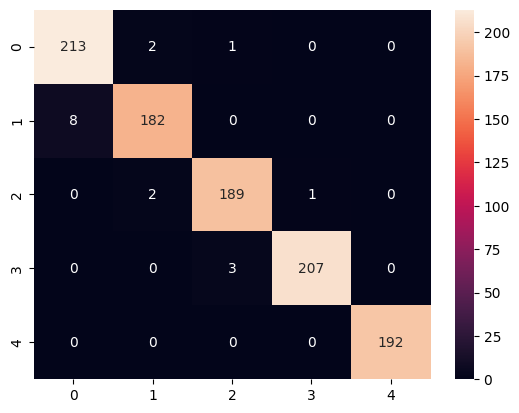

In [15]:
print('Matrice de confusion avec les KNNs')
cm=confusion_matrix(y_true,y_pred_KNN)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(y_true,y_pred_KNN))

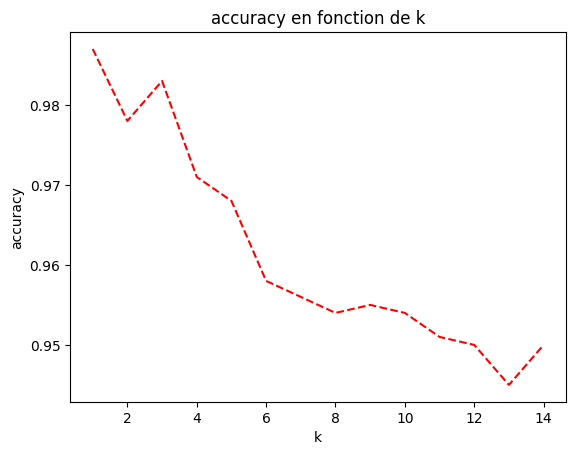

In [16]:
### Plot de l'accuarcy en fonction des nombres de voisins k

nbre_voisins = range(1,15)
accuracy_values = []
for k in nbre_voisins :
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh = neigh.fit(x, y)
    # Test sur les échantillons de DataECG_Test
    x_test = DataECGTest
    y_true = Label_test
    y_pred_KNN = neigh.predict(x_test)
    accuracy_values.append(accuracy_score(y_true,y_pred_KNN))

plt.figure()
plt.plot(nbre_voisins, accuracy_values, 'r--')
plt.title('accuracy en fonction de k')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()



## Méthodes non supervisées

Indiquer quelles sont les 2 méthodes non supervisées de votre choix et calculer la matrice de confusion associée.

### Avec DBScan

Matrice de confusion avec DBSCAN
Accuracy sur base de test : 0.216


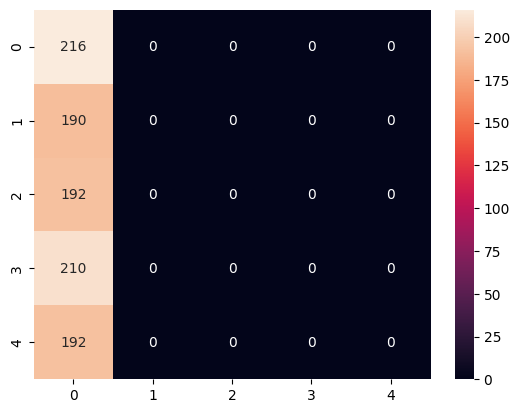

In [17]:
from sklearn.cluster import DBSCAN

# Les inputs de test
x = DataECGTest



# Instanciation du modèle
dbscan_model = DBSCAN(eps = 4 , min_samples=20).fit(x)

# Calcul des labels
labels_dbscan = dbscan_model.labels_

# Matrice de confusion et score d'accuracy
print('Matrice de confusion avec DBSCAN')
cm=confusion_matrix(Label_test,labels_dbscan)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(Label_test,labels_dbscan))



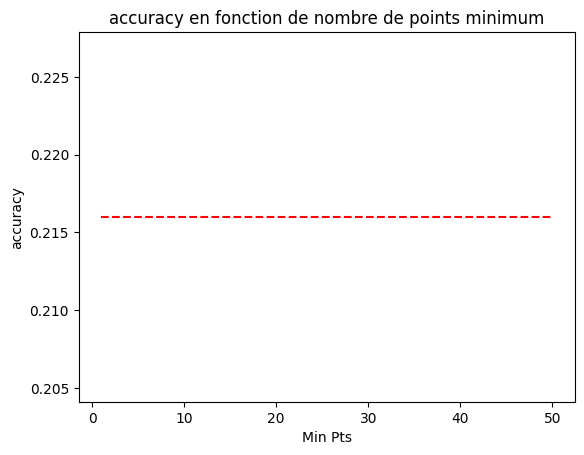

In [18]:
from sklearn.cluster import DBSCAN

# Les inputs de test
x = DataECGTest

# Les hyperparamètres
eps = range(1,101)
Min_pts = range(1,51)
accuracy_vals = []


for min_pt in Min_pts :

    # Instanciation du modèle
    dbscan_model = DBSCAN(eps = 25 , min_samples=min_pt).fit(x)

    # Calcul des labels
    labels_dbscan = dbscan_model.labels_

    # score de performance
    accuracy_vals.append(accuracy_score(Label_test,labels_dbscan))

plt.figure()
plt.plot(Min_pts, accuracy_vals, 'r--')
plt.title('accuracy en fonction de nombre de points minimum')
plt.xlabel('Min Pts')
plt.ylabel('accuracy')
plt.show()


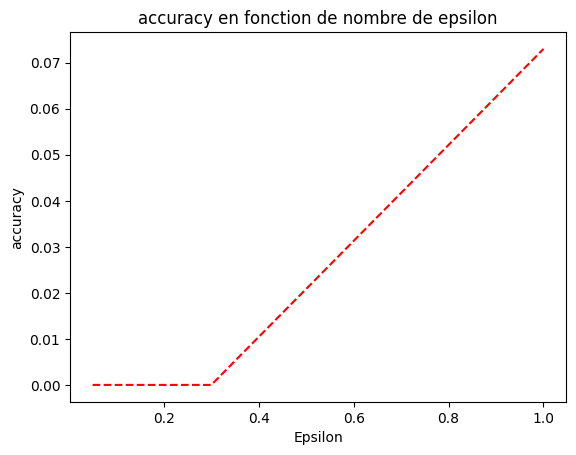

In [20]:
from sklearn.cluster import DBSCAN

# Les inputs de test
x = DataECGTest

# Les hyperparamètres
eps = [0.05 , 0.1 , 0.2 , 0.3 , 1 ]
Min_pts = range(1,51)
accuracy_vals = []


for epsilon in eps :

    # Instanciation du modèle
    dbscan_model = DBSCAN(eps = epsilon , min_samples=10  ).fit(x)

    # Calcul des labels
    labels_dbscan = dbscan_model.labels_

    # score de performance
    accuracy_vals.append(accuracy_score(Label_test,labels_dbscan))

plt.figure()
plt.plot(eps, accuracy_vals, 'r--')
plt.title('accuracy en fonction de nombre de epsilon')
plt.xlabel('Epsilon')
plt.ylabel('accuracy')
plt.show()

### Avec K-means



Matrice de confusion:


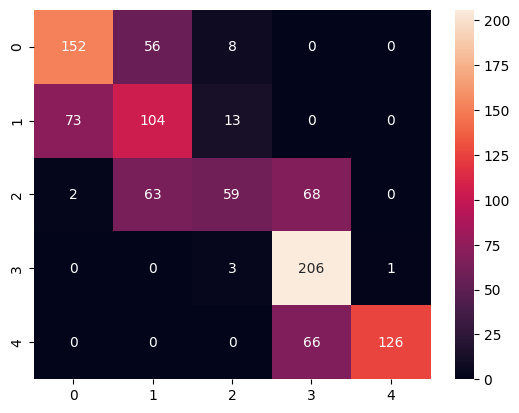

Accuracy sur base de test: 0.647


In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score

def retrieve_info(cluster_labels, y_train):
    unique_clusters = np.unique(cluster_labels)
    reference_labels = np.zeros(len(unique_clusters), dtype=int)

    y_train = y_train.astype(int)  # Conversion en int

    for i, cluster in enumerate(unique_clusters):
        mask = (cluster_labels == cluster)
        if np.any(mask):
            reference_labels[i] = np.bincount(y_train[mask]).argmax()

    return reference_labels

def correspondance(y_pred_kmeans, reference_labels):
    return np.array([reference_labels[label] for label in y_pred_kmeans])

# Données d'entraînement et de test
x_train = DataECGApp
y_train = Label_train

x_test = DataECGTest
y_true = Label_test


clf = KMeans(n_clusters=5, random_state=201)
y_train_pred = clf.fit_predict(x_train)


reference_labels = retrieve_info(y_train_pred, y_train)

y_pred_kmeans = clf.predict(x_test)


y_pred_mapped = correspondance(y_pred_kmeans, reference_labels)

# Calcul de la matrice de confusion
print('Matrice de confusion:')
cm = confusion_matrix(y_true, y_pred_mapped)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# Score de performance
print('Accuracy sur base de test:', accuracy_score(y_true, y_pred_mapped))

Accuracy maximale: 0.647
Valeur de random_state (k) correspondante: 201


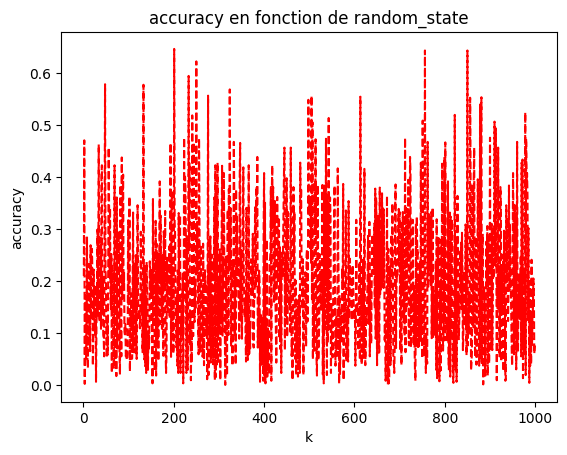

In [22]:
### Plot de l'accuarcy en fonction de random_state

random_state = range(1,1000)
accuracy_values = []
for k in random_state :
    neigh = KMeans(n_clusters=5,random_state=k)
    neigh = neigh.fit(x_train, y_train)
    # Test sur les échantillons de DataECG_Test
    x_test = DataECGTest
    y_true = Label_test
    y_pred_KNN = neigh.predict(x_test)
    accuracy_values.append(accuracy_score(y_true,y_pred_KNN))

max_accuracy = max(accuracy_values)
best_k = random_state[accuracy_values.index(max_accuracy)]

print(f"Accuracy maximale: {max_accuracy}")
print(f"Valeur de random_state (k) correspondante: {best_k}")
plt.figure()
plt.plot(random_state, accuracy_values, 'r--')
plt.title('accuracy en fonction de random_state')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

# Partie III : classification des battements cardiaques sur les features avec prétraitement par ACP

## Méthode supervisée avec réduction de dimension par ACP sur l'ensemble d'apprentissage
Réaliser une ACP sur l'ensemble d'apprentissage pour réduire la dimension, visualiser les données
puis projeter les données de l'ensemble de test dans la base de l'ACP.

Indiquer quelles sont les 2 méthodes supervisées de votre choix et calculer la matrice de confusion associée (confusion_matrix) et le score de performance (accuracy_score)

### Après réduction de la dimension , on réapplique tous les méthodes appliquées précedememnnt

In [23]:
from sklearn.decomposition import PCA

In [24]:
pca = PCA(n_components=5)
pca.fit(DataECGApp)

PCA(n_components=5)

In [25]:
sigma_app = pca.fit_transform(DataECGApp)
sigma_test = pca.transform(DataECGTest)

In [26]:
sigma_app.shape

(4000, 5)

In [27]:
sigma_test.shape

(1000, 5)

### On applique de nouveau les méthodes supervisées précedememnet  à savoir : SVM linéaire et les arbres de décision

1) Avec SVM (Entrainement et Test dans la même cellule)

Matrice de confusion par SVM et réduction de dimensions
Accuracy sur base de test : 1.0


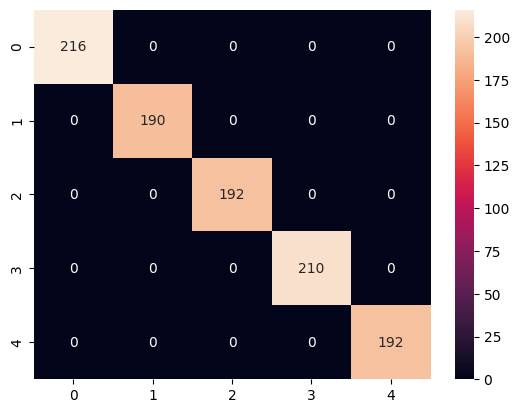

In [28]:
# Les inputs et les outputs d'entrainetement
x = sigma_app
y = Label_train

# Avec un kernel Linéair
lin_clf = svm.SVC(kernel='linear')

# Feeding the training data to the clf
lin_clf.fit(x, y)

# Test
x_test = sigma_test
y_true = Label_test
y_pred_acp = lin_clf.predict(x_test)

# Calcul de la matrice de confusion
print('Matrice de confusion par SVM et réduction de dimensions')
cm=confusion_matrix(y_true,y_pred_acp)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(y_true,y_pred_acp))

2) Avec Arbres de décision (Entrainement et Test dans la même cellule)

Matrice de confusion par arbres de décision et réduction de dimensions
Accuracy sur base de test : 0.992


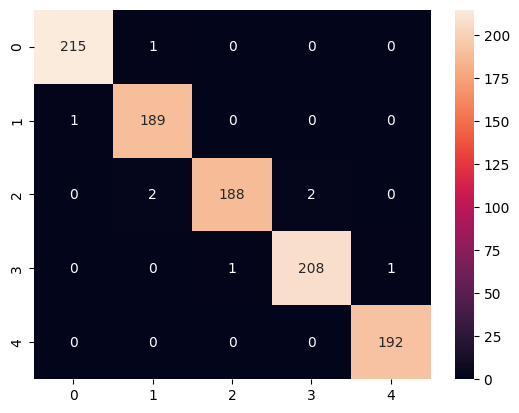

In [29]:
# Les inputs et les outputs d'entrainetement
x = sigma_app
y = Label_train

# Entrainer le classifieur
clf_DT_acp = tree.DecisionTreeClassifier()
clf = clf_DT_acp.fit(x, y)

# Test
x_test = sigma_test
y_true = Label_test
y_pred = clf_DT_acp.predict(x_test)


# Calcul de la matrice de confusion
print('Matrice de confusion par arbres de décision et réduction de dimensions')
cm=confusion_matrix(y_true,y_pred)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(y_true,y_pred))

### ACP avec l'algorithme KNNs


Matrice de confusion par KNNs et réduction de dimensions
Accuracy sur base de test : 0.997


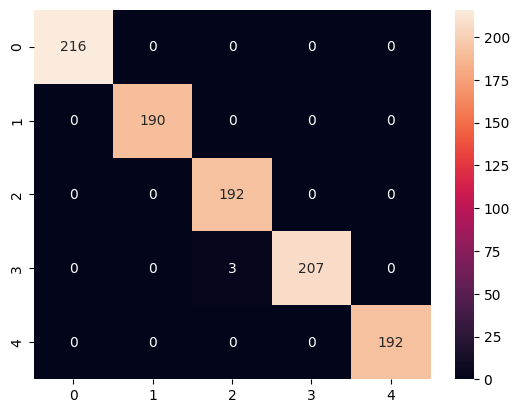

In [30]:
# Les inputs et les outputs d'entrainetement
x = sigma_app
y = Label_train
neigh = KNeighborsClassifier(n_neighbors=5)
neigh = neigh.fit(x, y)

# Test
x_test = sigma_test
y_true = Label_test
y_pred = neigh.predict(x_test)

# Calcul de la matrice de confusion
print('Matrice de confusion par KNNs et réduction de dimensions')
cm=confusion_matrix(y_true,y_pred)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(y_true,y_pred))

## Méthode non supervisée avec réduction de dimension par ACP sur l'ensemble des données

Réaliser une ACP sur l'ensemble des données et indiquer quelles sont les méthodes non supervisées de votre choix et calculer la matrice de confusion associée (confusion_matrix) et le score de performance (accuracy_score)

### ACP + DBScan

Matrice de confusion avec DBSCAN et ACP
Accuracy sur base de test : 0.216


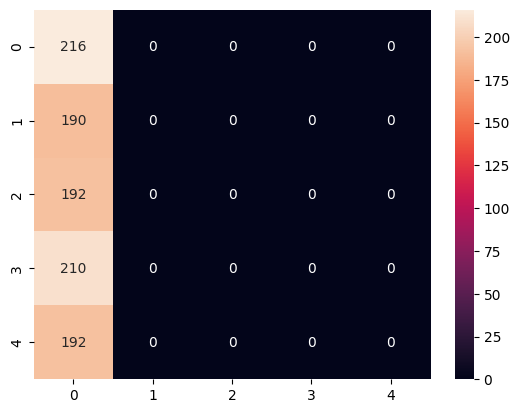

In [31]:
from sklearn.cluster import DBSCAN

# Les inputs de test
x = sigma_test

# Instanciation du modèle
dbscan_model = DBSCAN(eps = 1000 , min_samples=1000).fit(x)

# Calcul des labels
labels_dbscan_acp = dbscan_model.labels_

# Matrice de confusion et score d'accuracy
print('Matrice de confusion avec DBSCAN et ACP')
cm=confusion_matrix(Label_test,labels_dbscan_acp)
sns.heatmap(data=cm,fmt='.0f',annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(Label_test,labels_dbscan_acp))

### ACP + K-means

Matrice de confusion:


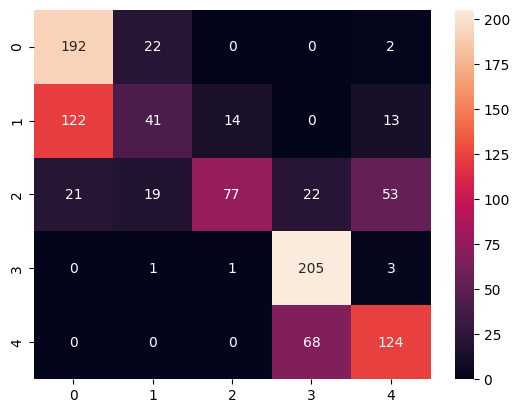

Accuracy sur base de test: 0.639


In [32]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score

def retrieve_info(cluster_labels, y_train):
    unique_clusters = np.unique(cluster_labels)
    reference_labels = np.zeros(len(unique_clusters), dtype=int)

    y_train = y_train.astype(int)  # Conversion en int

    for i, cluster in enumerate(unique_clusters):
        mask = (cluster_labels == cluster)
        if np.any(mask):
            reference_labels[i] = np.bincount(y_train[mask]).argmax()

    return reference_labels

def correspondance(y_pred_kmeans, reference_labels):
    return np.array([reference_labels[label] for label in y_pred_kmeans])

# Données d'entraînement et de test
x_train = sigma_app
y_train = Label_train


x_test = sigma_test
y_true = Label_test


clf = KMeans(n_clusters=5, random_state=201)
y_train_pred = clf.fit_predict(x_train)


reference_labels = retrieve_info(y_train_pred, y_train)

y_pred_kmeans = clf.predict(x_test)


y_pred_mapped = correspondance(y_pred_kmeans, reference_labels)

# Calcul de la matrice de confusion
print('Matrice de confusion:')
cm = confusion_matrix(y_true, y_pred_mapped)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# Score de performance
print('Accuracy sur base de test:', accuracy_score(y_true, y_pred_mapped))



# Réaliser votre étude :

- Etudier les meilleurs paramètres pour les méthodes supervisées et non supervisées que vous avez choisies.
- Faire une étude sur les paramètres issus de TSFEL en séparant par exemple les différentes modalités (statistiques,temporelles et spectrales) ou en étudiant leur correlation et essayer de réaliser des prétraitements.
- Optimiser la réduction de dimensions par ACP
